In [1]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import scipy.linalg as la
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from copy import deepcopy
import sys
from matplotlib.patches import Rectangle
from scipy.sparse.linalg import inv as spinv
from scipy.sparse import block_diag

from IPython.display import display, Latex

In [2]:
#spin Operators of Eu:YSO:
Espin = 0#1/2
Ispin = 5/2

muNf = 7.622593285 #MHz/T
#muNf*=(1E6/1E4)*1E-3 #kHz/G

#Initialise the class with its electronic and nuclear spin, for both ground and excited state
ground = spin.cSpinHamiltonian(Espin,Ispin)

#M tensor ground state
M = np.matrix(np.diag([2.86,3.05,11.56]))*10*1E6*spin.h#convert kHz/G to MHz/T  to J/T      #/muNf#*muNf#*1E-4#/muNf#*1E-1#*spin.h*spin.muN
#Q tensor ground state
Q = np.matrix(np.diag([-0.5624,0.5624,4.4450]))*1E6*spin.h #MHz*h

eRot= 'ZYZ'

#rotated tensors
M_rot = np.array([-99.7,55.7,-40])*np.pi/180
Q_rot = np.array([-94,58.1,-20.7])*np.pi/180

M_G = spin.tensorRotation(M,M_rot,str=eRot,dumb=True)#ZYZ
Q_G = spin.tensorRotation(Q,Q_rot,str=eRot,dumb=True)

ground.quadrupoleInteraction(Q_G)
ground.setM(M_G)
ground.setgN(None)


In [3]:
def Inverse_iteration(A, V,u,num_iterations: int):
    # Ideally choose a random vector
    # To decrease the chance that our vector
    # Is orthogonal to the eigenvector
    b_k = V
    U=np.linalg.inv(A-u*np.eye((A.shape[0])))
    #val=1
    for _ in range(num_iterations):
        # calculate the matrix-by-vector product Ab
        b_k1 = np.dot(U, b_k)

        # calculate the norm
        b_k1_norm = np.linalg.norm(b_k1)

        # re normalize the vector
        b_k = b_k1 / b_k1_norm
        #print(b_k1_norm)
    val=np.real(A@b_k/b_k)[0].item()
    #print(val,1/b_k1_norm)
    return val,b_k

def full(H,t):
    F,V =np.linalg.eigh(H)
    return F[t],V[:,t]


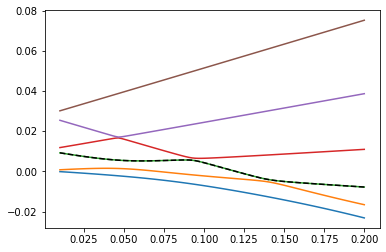

In [4]:
Bf=0.2
xs=np.linspace(0.01,Bf,100)

FT=np.zeros((len(xs),ground.dim))
FA=np.zeros(len(xs))
t = 2

for i,x in enumerate(xs):

    B = np.matrix([0,1,0]).T*x
    HG = ground.H+ground.nuclearZeeman(B)#/spin.muN
    FG,VG =np.linalg.eigh(HG)

    if i==0:
        FGt,VGt=Inverse_iteration(HG,VG[t].T,FG[t],1)
    FGt,VGt=Inverse_iteration(HG,VGt,FGt,1)
    FT[i,:]=FG/(spin.h*1e9)
    FA[i]=FGt/(spin.h*1e9)


plt.plot(xs,FT)
plt.plot(xs,FA,'k--')
plt.show()
plt.close()


In [5]:
%timeit Inverse_iteration(HG,VGt,FGt,1)
%timeit full(HG,t)


271 µs ± 30.6 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
41.2 µs ± 4.66 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [6]:
from pathos.multiprocessing import ProcessingPool as Pool
def add(x,y):
    return x+y
def test(x):
    return x,ground.Idim
x=[0,1,2,4]
y=[4,5,6,7]
#p=Pool()
with Pool() as p:
    print(p.map(add,x,y))

[4, 6, 8, 11]


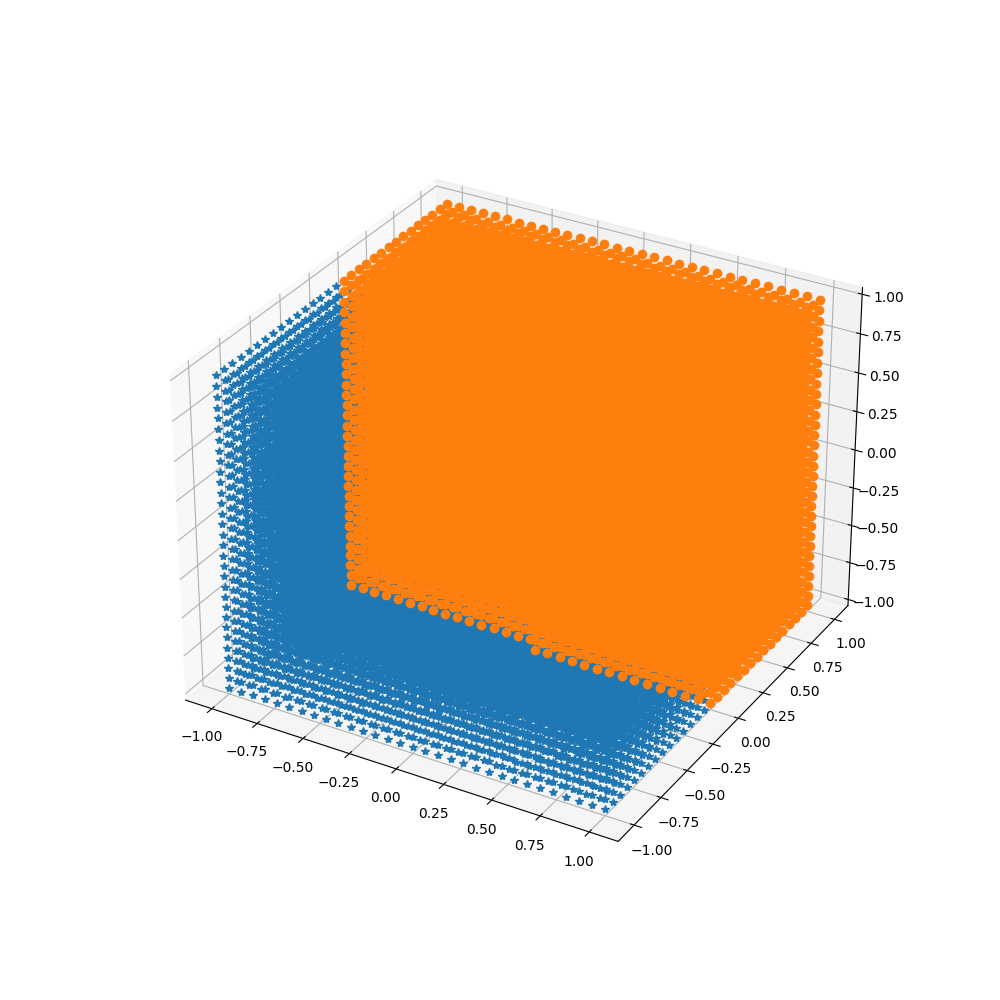

In [47]:
%matplotlib widget
n=31
dim=3

h=int(n/2)+1
half=int((n**dim)/2)+1
Bxi = np.linspace(-1,1,n)
Byi = Bxi
Bzi = Bxi
X,Y,Z=np.meshgrid(Bxi,Byi,Bzi)
Bsi = np.array([X,Y,Z]).reshape(dim,-1).T
#print(Bsi[:half,:],Bsi[:half,:].shape)
Bsh=np.array([X[:,:h],Y[:,:h],Z[:,:h]]).reshape(dim,-1).T
#print(Bsh,Bsh.shape)

#print("\n",X[:,:h],Y[:,:h])
fig=plt.figure(figsize=(10,10))
ax=fig.add_subplot(projection='3d')
#ax.plot(*Bsi.T,'r*')
ax.plot(*Bsi[:half,:].T,'*')
ax.plot(*(-1*Bsi[:half,:].T),'o')

plt.show()
#plt.close()